## 1. Import Required Libraries

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Import cosmocore modules
from cosmocore import (
    InputParams,
    compute_signal_matrix,
    read_maps,
)
from cosmocore._mpi import MPI

# Import qube modules
from picslike import PICSLike

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [2]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [3]:
PICSLIKE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))


def resolve_config(config_rel, overrides=None):
    """Anchor YAML paths to picslike root so the notebook runs from any cwd."""
    full_path = os.path.join(PICSLIKE_ROOT, config_rel)
    with open(full_path) as f:
        config = yaml.safe_load(f)
    for key, value in config.items():
        if isinstance(value, str):
            clean = value
            while clean.startswith("../"):
                clean = clean[3:]
            if clean.startswith("tests/") or clean.startswith("scripts/"):
                config[key] = os.path.join(PICSLIKE_ROOT, clean)
    if overrides:
        config.update(overrides)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yaml", delete=False)
    yaml.dump(config, tmp, default_flow_style=False)
    tmp.close()
    return tmp.name

In [4]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "TQU"  # Use TQU configuration for debugging
nside = 4
param_file = resolve_config(f"tests/data/nside{nside}/{fields}/config.yaml")

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"physical_labels: {getattr(params, 'physical_labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/notebooks
Parameter file: /tmp/tmpwro251b0.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [0, 2]
labels: ['T', 'E', 'B']
physical_labels: ['T', 'Q', 'U']
nspectra: 6
lmax: 16
nsims: 100
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [5]:
# Initialize Spectra instance
print("Creating Spectra instance...")
likelihood = PICSLike(param_file)

# Display MPI and basic info
print(f"MPI rank: {likelihood.rank}")
print(f"MPI size: {likelihood.size}")
print(f"Parameters loaded: {likelihood.params is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {likelihood.maps1}")

Creating Spectra instance...
2026-05-15 15:06:43 | picslike     | INFO     | PICSLike initialized!


MPI rank: 0
MPI size: 1
Parameters loaded: True

=== Initial Variable States ===
maps1: None


## 4. Setup Fields and Geometry

In [6]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
likelihood.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
likelihood.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"nside: {params.nside}")
print(f"Total pixels: {params.nside**2 * 12}")
print(f"npixs type: {type(likelihood.npixs)}")
print(f"npixs: {likelihood.npixs}")
print(f"n_active: {likelihood.collection.n_active}")
print(f"Total pixels: {sum(likelihood.collection.n_active)}")

if hasattr(likelihood, "pixact") and likelihood.pixact is not None:
    print(f"pixact type: {type(likelihood.pixact)}")
    print(f"pixact length: {len(likelihood.pixact)}")
    for i, pix in enumerate(likelihood.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"\nSpectra labels: {likelihood.collection.spectra_labels}")
    print(f"Number of spectra: {len(likelihood.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print('Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]')
    print(f"Actual spectra: {likelihood.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
nside: 4
Total pixels: 192
npixs type: <class 'list'>
npixs: [192, 192]
n_active: [192, 192, 192]
Total pixels: 576
pixact type: <class 'numpy.ndarray'>
pixact length: 3
  Field 0: 192 active pixels
  Field 1: 192 active pixels
  Field 2: 192 active pixels

Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6
Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]
Actual spectra: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']


## 5. Load Maps Data

In [7]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(likelihood.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")

likelihood.maps1 = np.empty((ntot, likelihood.params.nsims), dtype=np.float64)
read_maps(
    maps=likelihood.maps1,
    filename=likelihood.params.inputmapfile1,
    pixact=likelihood.pixact,
    field_labels=likelihood.params.physical_labels,
    calibration=likelihood.params.calibration,
)
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {likelihood.maps1.shape}")
print(f"maps1 dtype: {likelihood.maps1.dtype}")
print(f"maps1 min/max: {likelihood.maps1.min():.3e} / {likelihood.maps1.max():.3e}")
print(f"maps1 mean/std: {likelihood.maps1.mean():.3e} / {likelihood.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 576


Maps loaded

=== Maps1 Info ===
maps1 shape: (576, 100)
maps1 dtype: float64
maps1 min/max: -1.577e+02 / 1.664e+02
maps1 mean/std: 2.608e-04 / 2.315e+01


## 6. Load Covariance Matrices

In [8]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")
likelihood.setup_covariance_matrices()


# Load noise_cov1 (noise covariance matrix)
print(f"Loading noise_cov1 from: {likelihood.params.covmatfile1}")
likelihood.noise_cov1 = np.fromfile(likelihood.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"\nnoise_cov1 shape: {likelihood.noise_cov1.shape}")
print(f"noise_cov1 dtype: {likelihood.noise_cov1.dtype}")

=== Loading covariance matrices ===
Loading noise_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.picslike/tests/data/nside4/TQU/NCVM1.bin

=== Covariance Matrix Info ===

noise_cov1 shape: (576, 576)
noise_cov1 dtype: float64


## 7. Setup Cls and Beams

In [9]:
print("=== Setting up Cls ===")
likelihood.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
likelihood.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(likelihood, "collection") and likelihood.collection is not None:
    print(f"Collection type: {type(likelihood.collection)}")

    # Get spectra manager info
    if hasattr(likelihood.collection, "spectra_manager"):
        mgr = likelihood.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(likelihood.collection, "beam_manager"):
        print(
            f"\nBeam manager available: {likelihood.collection.beam_manager is not None}"
        )
else:
    print("Collection not available")

=== Setting up Cls ===


2026-05-15 15:06:44 | picslike     | DETAILS  | Read Cls: (1499, 7) ['ell', 'TT', 'EE', 'BB', 'TE', 'TB', 'EB']


Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6

=== Reference Cls Values (first few ell) ===
TT: [   0.            0.         1059.36209487  491.52024463  271.50038353] (ell=2-6)
EE: [0.         0.         0.03603948 0.02405363 0.01299698] (ell=2-6)
BB: [0.00000000e+00 0.00000000e+00 1.77551662e-06 1.74076553e-06
 1.69548417e-06] (ell=2-6)
EB: [0. 0. 0. 0. 0.] (ell=2-6)
TE: [0.         0.         2.8793977  1.61880689 0.90506453] (ell=2-6)
TB: [0. 0. 0. 0. 0.] (ell=2-6)

Beam manager available: True


## 8. Smoothing factors (now internalised)

In [10]:
# Display loaded beams (diagnostic only).
# Previously this cell built a `clnorm = b² × 2π/[ℓ(ℓ+1)]` factor that the
# parameter-scan loop multiplied into spectra by hand. PICSLike now applies
# beam smoothing internally via `collection.set_beams(lmax=lmax_signal)`,
# and `parameter_grid.get_spectrum` returns spectra already blended with
# the fiducial in the inference window, so no manual clnorm is needed.
beam_T = likelihood.collection.fields[0].beam
beam_P = likelihood.collection.fields[1].beam[:, 0]

print(f"Beam T (first 5): {beam_T[:5]}")
print(f"Beam P (first 5): {beam_P[:5]}")
print(
    f"lmax_signal = {likelihood.lmax_signal}, lmax (inference) = {likelihood.params.lmax}"
)

Beam T (first 5): [1.         0.99668762 0.99009568 0.98028926 0.96736465]
Beam P (first 5): [0.         0.         0.99668769 0.98681611 0.97380562]
lmax_signal = 16, lmax (inference) = 16


In [11]:
# Smoothing factors are now applied internally.
# Previously this cell built a `vecmul` array of beam-smoothing factors and stored
# it on the likelihood instance. With beam smoothing absorbed into the framework
# (collection.set_beams() in the parameter scan below applies it via apply_smoothing,
# and parameter_grid.get_spectrum returns spectra already blended with the fiducial),
# the manual vecmul is no longer needed. Kept as an explanatory marker; nothing
# downstream consumes it.
print("Smoothing factors are now applied inside collection.set_beams() — see cell below.")

Smoothing factors are now applied inside collection.set_beams() — see cell below.


## 9. Load and Process Fisher Matrix

In [12]:
print("=== Loading Fisher matrix ===")
likelihood.setup_parameter_grid()

grid = likelihood.parameter_grid.grid_points

print(f"Parameter grid points: {grid}")

=== Loading Fisher matrix ===
2026-05-15 15:06:44 | picslike     | DEBUG    | Setting up parameter grid...


2026-05-15 15:06:44 | picslike     | DEBUG    | Parameter grid contains 121 points


Parameter grid points: [(np.float64(0.95), np.float64(-0.2)), (np.float64(0.95), np.float64(-0.16)), (np.float64(0.95), np.float64(-0.12000000000000001)), (np.float64(0.95), np.float64(-0.08000000000000002)), (np.float64(0.95), np.float64(-0.04000000000000001)), (np.float64(0.95), np.float64(0.0)), (np.float64(0.95), np.float64(0.03999999999999998)), (np.float64(0.95), np.float64(0.08000000000000002)), (np.float64(0.95), np.float64(0.12)), (np.float64(0.95), np.float64(0.15999999999999998)), (np.float64(0.95), np.float64(0.2)), (np.float64(0.96), np.float64(-0.2)), (np.float64(0.96), np.float64(-0.16)), (np.float64(0.96), np.float64(-0.12000000000000001)), (np.float64(0.96), np.float64(-0.08000000000000002)), (np.float64(0.96), np.float64(-0.04000000000000001)), (np.float64(0.96), np.float64(0.0)), (np.float64(0.96), np.float64(0.03999999999999998)), (np.float64(0.96), np.float64(0.08000000000000002)), (np.float64(0.96), np.float64(0.12)), (np.float64(0.96), np.float64(0.15999999999999

In [13]:
from tqdm import tqdm

In [14]:
# Parameter scan — mirrors PICSLike._compute_likelihood_point (no-basis path).
# Per parameter point: build signal matrix via collection.set_cls/set_beams +
# compute_signal_matrix, form C = N + S, invert, evaluate Gaussian likelihood.
from cosmocore.basics import matrix_inverse_symm, matrix_slogdet_symm

like_values = np.zeros(
    (
        len(likelihood.parameter_ranges["amplitude"]),
        len(likelihood.parameter_ranges["tilt"]),
        likelihood.params.nsims,
    )
)
chi2_values = np.zeros_like(like_values)

for i, amp in enumerate(tqdm(likelihood.parameter_ranges["amplitude"])):
    for j, tilt in enumerate(likelihood.parameter_ranges["tilt"]):
        param_point = (amp, tilt)

        # parameter_grid returns the spectrum already blended with the fiducial
        # outside the inference window (parameter_grid.py:217-219).
        spectra_dict = likelihood.parameter_grid.get_spectrum(param_point)

        # set_cls + set_beams together apply beam smoothing internally
        # (fields.py:952-963 -> apply_smoothing).
        likelihood.collection.set_cls(spectra_dict, lmax=likelihood.lmax_signal)
        likelihood.collection.set_beams(lmax=likelihood.lmax_signal)

        likelihood.signal_matrix = np.zeros_like(likelihood.noise_cov1, dtype=np.float64)
        likelihood.signal_matrix = np.asfortranarray(likelihood.signal_matrix)
        compute_signal_matrix(
            S=likelihood.signal_matrix,
            lmax=likelihood.lmax_signal,
            fields=likelihood.collection,
        )

        total_cov = likelihood.noise_cov1 + likelihood.signal_matrix
        inv_total_cov = matrix_inverse_symm(total_cov)
        det = matrix_slogdet_symm(total_cov)[1]

        # chi² = d^T C^{-1} d alone is monotone in signal amplitude and does not
        # peak at the truth — parameter inference must minimize -2 log L = chi² + logdet.
        chi_squared = np.einsum(
            "in,ij,jn->n", likelihood.maps1, inv_total_cov, likelihood.maps1
        )
        neg2_log_like = chi_squared + det
        chi2_values[i, j] = neg2_log_like
        like_values[i, j] = -0.5 * neg2_log_like

  0%|          | 0/11 [00:00<?, ?it/s]

  9%|▉         | 1/11 [00:10<01:41, 10.10s/it]

 18%|█▊        | 2/11 [00:13<00:55,  6.19s/it]

 27%|██▋       | 3/11 [00:16<00:39,  4.90s/it]

 36%|███▋      | 4/11 [00:19<00:27,  3.92s/it]

...

 73%|███████▎  | 8/11 [00:39<00:15,  5.16s/it]

 82%|████████▏ | 9/11 [00:44<00:09,  4.97s/it]

 91%|█████████ | 10/11 [00:49<00:05,  5.02s/it]

100%|██████████| 11/11 [00:54<00:00,  5.03s/it]

100%|██████████| 11/11 [00:54<00:00,  4.98s/it]

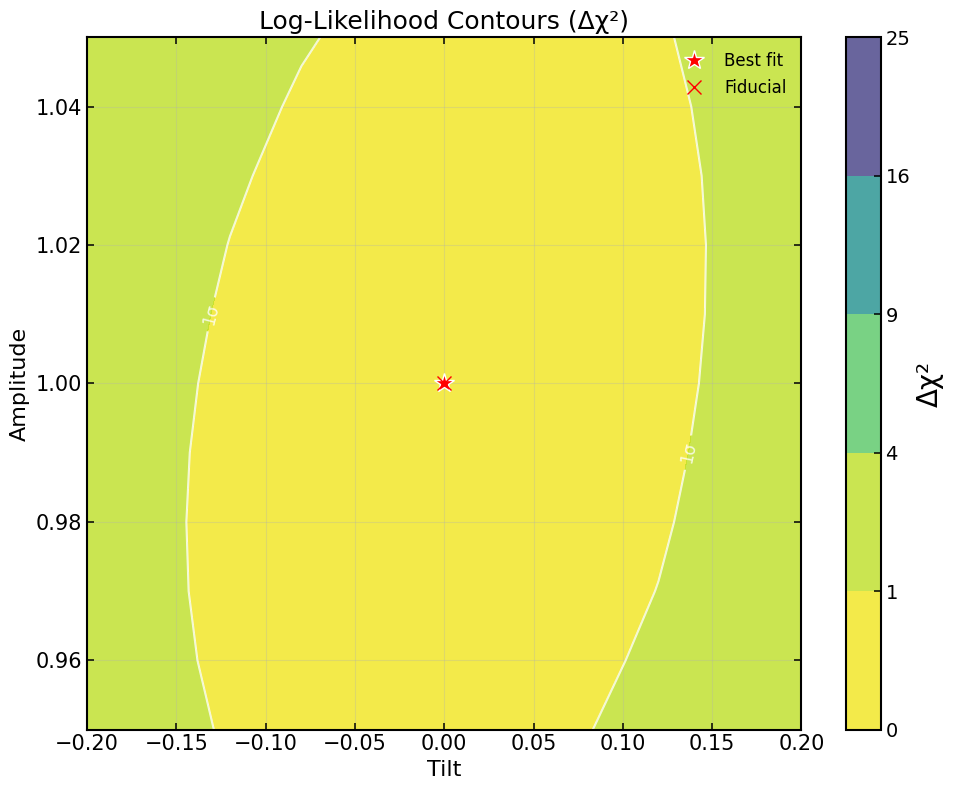

Best-fit parameters: Amplitude = 1.0000, Tilt = 0.0000
Minimum χ² = -773.23
Contour plot with confidence intervals displayed.


In [15]:
# Create contour plot for log-likelihood
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare the data
chi2_mean = chi2_values.mean(axis=-1)
delta_chi2 = chi2_mean - chi2_mean.min()

# Create coordinate grids
tilt_grid, amp_grid = np.meshgrid(
    likelihood.parameter_ranges["tilt"], likelihood.parameter_ranges["amplitude"]
)

# Create filled contour plot
contour_levels = [0, 1, 4, 9, 16, 25]  # Corresponding to 0σ, 1σ, 2σ, 3σ, 4σ, 5σ
contourf = ax.contourf(
    tilt_grid, amp_grid, delta_chi2, levels=contour_levels, cmap="viridis_r", alpha=0.8
)

# Add contour lines
contour_lines = ax.contour(
    tilt_grid,
    amp_grid,
    delta_chi2,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    alpha=0.8,
)

# Add contour labels
ax.clabel(contour_lines, inline=True, fontsize=12, fmt="%dσ")

# Find and mark the best-fit point
min_idx = np.unravel_index(np.argmin(chi2_mean), chi2_mean.shape)
best_tilt = likelihood.parameter_ranges["tilt"][min_idx[1]]
best_amp = likelihood.parameter_ranges["amplitude"][min_idx[0]]

ax.plot(
    best_tilt,
    best_amp,
    "r*",
    markersize=15,
    label="Best fit",
    markeredgecolor="white",
    markeredgewidth=1,
)

ax.plot(
    0.0,
    1.0,
    "bx",
    markersize=10,
    label="Fiducial",
    markeredgecolor="red",
    markeredgewidth=1,
)

# Customize the plot
ax.set_xlabel("Tilt", fontsize=16)
ax.set_ylabel("Amplitude", fontsize=16)
ax.set_title("Log-Likelihood Contours (Δχ²)", fontsize=18)

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, label="Δχ²")
cbar.ax.tick_params(labelsize=14)

# Add legend
ax.legend(fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best-fit parameters: Amplitude = {best_amp:.4f}, Tilt = {best_tilt:.4f}")
print(f"Minimum χ² = {chi2_mean.min():.2f}")
print("Contour plot with confidence intervals displayed.")

In [16]:
# Equivalent to running the full likelihood in one step
print("=== Running full likelihood ===")
full_like = PICSLike(param_file)

full_like.run()

=== Running full likelihood ===
2026-05-15 15:07:40 | picslike     | INFO     | PICSLike initialized!


2026-05-15 15:07:40 | picslike     | DEBUG    | Setting up parameter grid...


2026-05-15 15:07:40 | picslike     | DEBUG    | Parameter grid contains 121 points


2026-05-15 15:07:40 | picslike     | INFO     | Starting PICSLike analysis pipeline


2026-05-15 15:07:40 | picslike     | DETAILS  | Read Cls: (1499, 7) ['ell', 'TT', 'EE', 'BB', 'TE', 'TB', 'EB']


...

2026-05-15 15:10:40 | picslike     | DETAILS  | Computed inverse of primary covariance matrix


2026-05-15 15:10:40 | picslike     | VERBOSE  | Total covariance matrix prepared and inverted


2026-05-15 15:10:41 | picslike     | VERBOSE  | Log-determinant: -1335.80


2026-05-15 15:10:41 | picslike     | INFO     | Likelihood computation completed for 100 simulations


2026-05-15 15:10:41 | picslike     | DEBUG    | Mean likelihood result computed for analysis


In [17]:
full_like.get_chi_squared().shape

(121,)

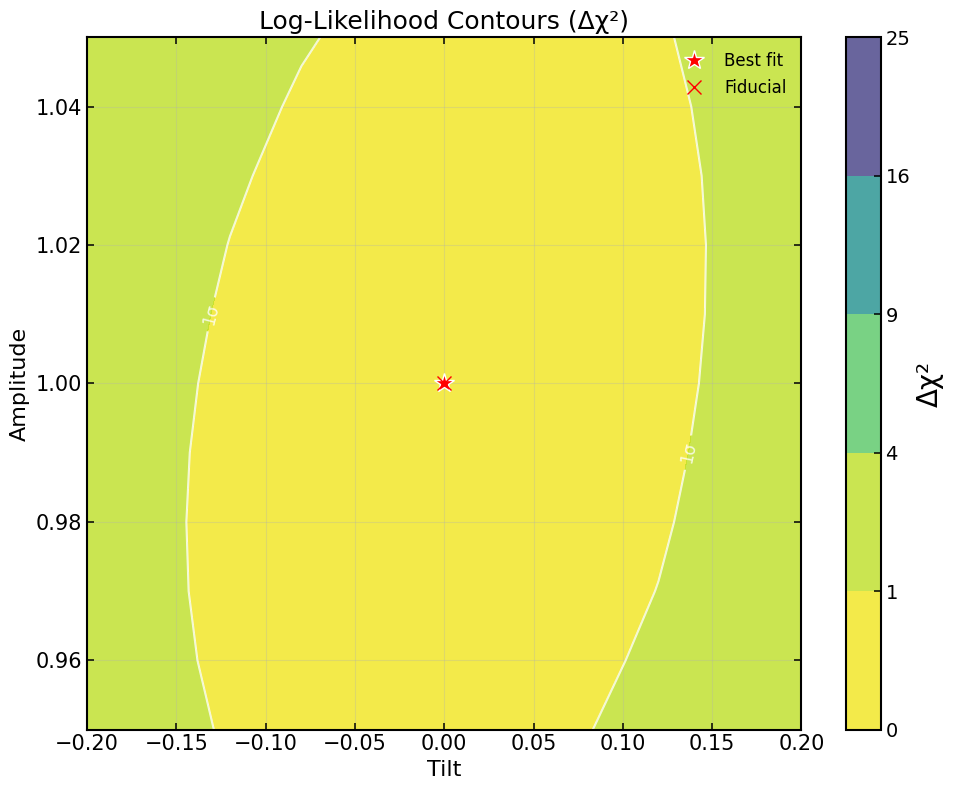

Best-fit parameters: Amplitude = 1.0000, Tilt = 0.0000
Minimum χ² = -773.23
Contour plot with confidence intervals displayed.


In [18]:
# Create contour plot for log-likelihood
fig, ax = plt.subplots(figsize=(10, 8))

# Prepare the data
# Use -2 log L (= chi² + logdet) so the minimum lands at the maximum-likelihood
# parameters, not at whichever parameter regime trivially maximises signal amplitude.
# Flat array order is (amp_outer, tilt_inner) -> reshape gives [i,j]=(amp[i],tilt[j]).
neg2_logL = -2 * full_like.get_log_likelihood()
chi2_mean = neg2_logL.reshape(11, -1)
delta_chi2 = chi2_mean - chi2_mean.min()

# Create coordinate grids
tilt_grid, amp_grid = np.meshgrid(
    full_like.parameter_ranges["tilt"], full_like.parameter_ranges["amplitude"]
)

# Create filled contour plot
contour_levels = [0, 1, 4, 9, 16, 25]  # Corresponding to 0σ, 1σ, 2σ, 3σ, 4σ, 5σ
contourf = ax.contourf(
    tilt_grid, amp_grid, delta_chi2, levels=contour_levels, cmap="viridis_r", alpha=0.8
)

# Add contour lines
contour_lines = ax.contour(
    tilt_grid,
    amp_grid,
    delta_chi2,
    levels=contour_levels,
    colors="white",
    linewidths=1.5,
    alpha=0.8,
)

# Add contour labels
ax.clabel(contour_lines, inline=True, fontsize=12, fmt="%dσ")

# Find and mark the best-fit point
min_idx = np.unravel_index(np.argmin(chi2_mean), chi2_mean.shape)
best_tilt = full_like.parameter_ranges["tilt"][min_idx[1]]
best_amp = full_like.parameter_ranges["amplitude"][min_idx[0]]

ax.plot(
    best_tilt,
    best_amp,
    "r*",
    markersize=15,
    label="Best fit",
    markeredgecolor="white",
    markeredgewidth=1,
)

ax.plot(
    0.0,
    1.0,
    "bx",
    markersize=10,
    label="Fiducial",
    markeredgecolor="red",
    markeredgewidth=1,
)

# Customize the plot
ax.set_xlabel("Tilt", fontsize=16)
ax.set_ylabel("Amplitude", fontsize=16)
ax.set_title("Log-Likelihood Contours (Δχ²)", fontsize=18)

# Add colorbar
cbar = plt.colorbar(contourf, ax=ax, label="Δχ²")
cbar.ax.tick_params(labelsize=14)

# Add legend
ax.legend(fontsize=12)

# Add grid for better readability
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best-fit parameters: Amplitude = {best_amp:.4f}, Tilt = {best_tilt:.4f}")
print(f"Minimum χ² = {chi2_mean.min():.2f}")
print("Contour plot with confidence intervals displayed.")